# Setup

In [1]:
%load_ext autoreload
%autoreload 2

# %matplotlib widget

In [2]:
from rich import print
import pandas as pd
import matplotlib.pyplot as plt



from tpvalidator.viz.tps import TrgPrimitivesPlotter



# Data

In [8]:
import tpvalidator.datacatalogue as dctl

dataset_names = ['eminus', 'radbkg']
# datasets = dctl.load('data/vd/1x8x14/3sig', load_rawadc=False, selection=dataset_names)
# datasets = dctl.load('data/vd/1x8x14/preprod', load_rawadc=False, selection=dataset_names)
datasets = dctl.load('data/vd/1x8x14/filtered', load_rawadc=False, selection=dataset_names)
rad_ws=datasets['radbkg']
em_ws=datasets['eminus']


Loading radbkg

Dataset 'radbkg': 5000 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [
        [28, 'Rn222ChainFromPo218GenInUpperMesh1x8x14'],
        [27, 'Rn220ChainFromPb212GenInUpperMesh1x8x14'],
        [26, 'Kr85GenInLAr'],
        [25, 'Rn222ChainFromBi210GenInUpperMesh1x8x14'],
        [24, 'U238ChainGenInAnode'],
        [23, 'K40GenInCathode'],
        [22, 'K42From42ArGenInUpperMesh1x8x14'],
        [21, 'Th232ChainGenInCathode'],
        [20, 'CavernNGammasAtLAr1x8x14'],
        [19, 'Rn222ChainRn222GenInLAr'],
        [18, 'U238ChainGenInCathode'],
        [17, 'K40GenInAnode'],
        [16, 'Rn220ChainPb212GenInLAr'],
        [15, 'foamGammasAtLAr1x8x14'],
        [14, 'Rn222ChainFromPb214GenInUpperMesh1x8x14'],
        [13, 'K42From42ArGenInLAr'],
        [12, 'Rn222ChainGenInPDS'],
        [11, 'Ar42GenInLAr'],
        [10, 'CavernwallGammasAtLAr1x8x14'],
        [9, 'Rn222ChainPb210GenInLAr'],
        [8, 'Ar39GenInLAr'],
        [7, 'Rn222ChainPb214GenInLAr'],
        [6, 'Rn222ChainFromPb210GenInUpperMesh1x8x14'],
        [5, 'Rn222ChainPo218GenInLAr'],
        [4, 'CavernwallNeutronsAtLAr1x8x14'],
        [3, 'Rn222ChainFromBi214GenInUpperMesh1x8x14'],
        [2, 'CryostatNGammasAtLAr1x8x14'],
        [1, 'Th232ChainGenInAnode'],
        [0, 'Rn222ChainBi214GenInLAr']
    ],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 36,
            'threshold_tpg_plane1': 36,
            'threshold_tpg_plane2': 36,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

Loading eminus

Dataset 'eminus': 10000 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [[0, 'generator']],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 36,
            'threshold_tpg_plane1': 36,
            'threshold_tpg_plane2': 36,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

In [9]:
rad_ws.info['mctruth_blockid_map']

[[28, 'Rn222ChainFromPo218GenInUpperMesh1x8x14'],
 [27, 'Rn220ChainFromPb212GenInUpperMesh1x8x14'],
 [26, 'Kr85GenInLAr'],
 [25, 'Rn222ChainFromBi210GenInUpperMesh1x8x14'],
 [24, 'U238ChainGenInAnode'],
 [23, 'K40GenInCathode'],
 [22, 'K42From42ArGenInUpperMesh1x8x14'],
 [21, 'Th232ChainGenInCathode'],
 [20, 'CavernNGammasAtLAr1x8x14'],
 [19, 'Rn222ChainRn222GenInLAr'],
 [18, 'U238ChainGenInCathode'],
 [17, 'K40GenInAnode'],
 [16, 'Rn220ChainPb212GenInLAr'],
 [15, 'foamGammasAtLAr1x8x14'],
 [14, 'Rn222ChainFromPb214GenInUpperMesh1x8x14'],
 [13, 'K42From42ArGenInLAr'],
 [12, 'Rn222ChainGenInPDS'],
 [11, 'Ar42GenInLAr'],
 [10, 'CavernwallGammasAtLAr1x8x14'],
 [9, 'Rn222ChainPb210GenInLAr'],
 [8, 'Ar39GenInLAr'],
 [7, 'Rn222ChainPb214GenInLAr'],
 [6, 'Rn222ChainFromPb210GenInUpperMesh1x8x14'],
 [5, 'Rn222ChainPo218GenInLAr'],
 [4, 'CavernwallNeutronsAtLAr1x8x14'],
 [3, 'Rn222ChainFromBi214GenInUpperMesh1x8x14'],
 [2, 'CryostatNGammasAtLAr1x8x14'],
 [1, 'Th232ChainGenInAnode'],
 [0, 'Rn222

# Pre-Run Checks

## Background and Signal TPs properties
A routine check to confirm the absense of macroscopic features in the input datasets, and that the samples were properly filtered.

Min samples_over_threshold = 9

Min adc_peak = 46

Min adc_integral = 351

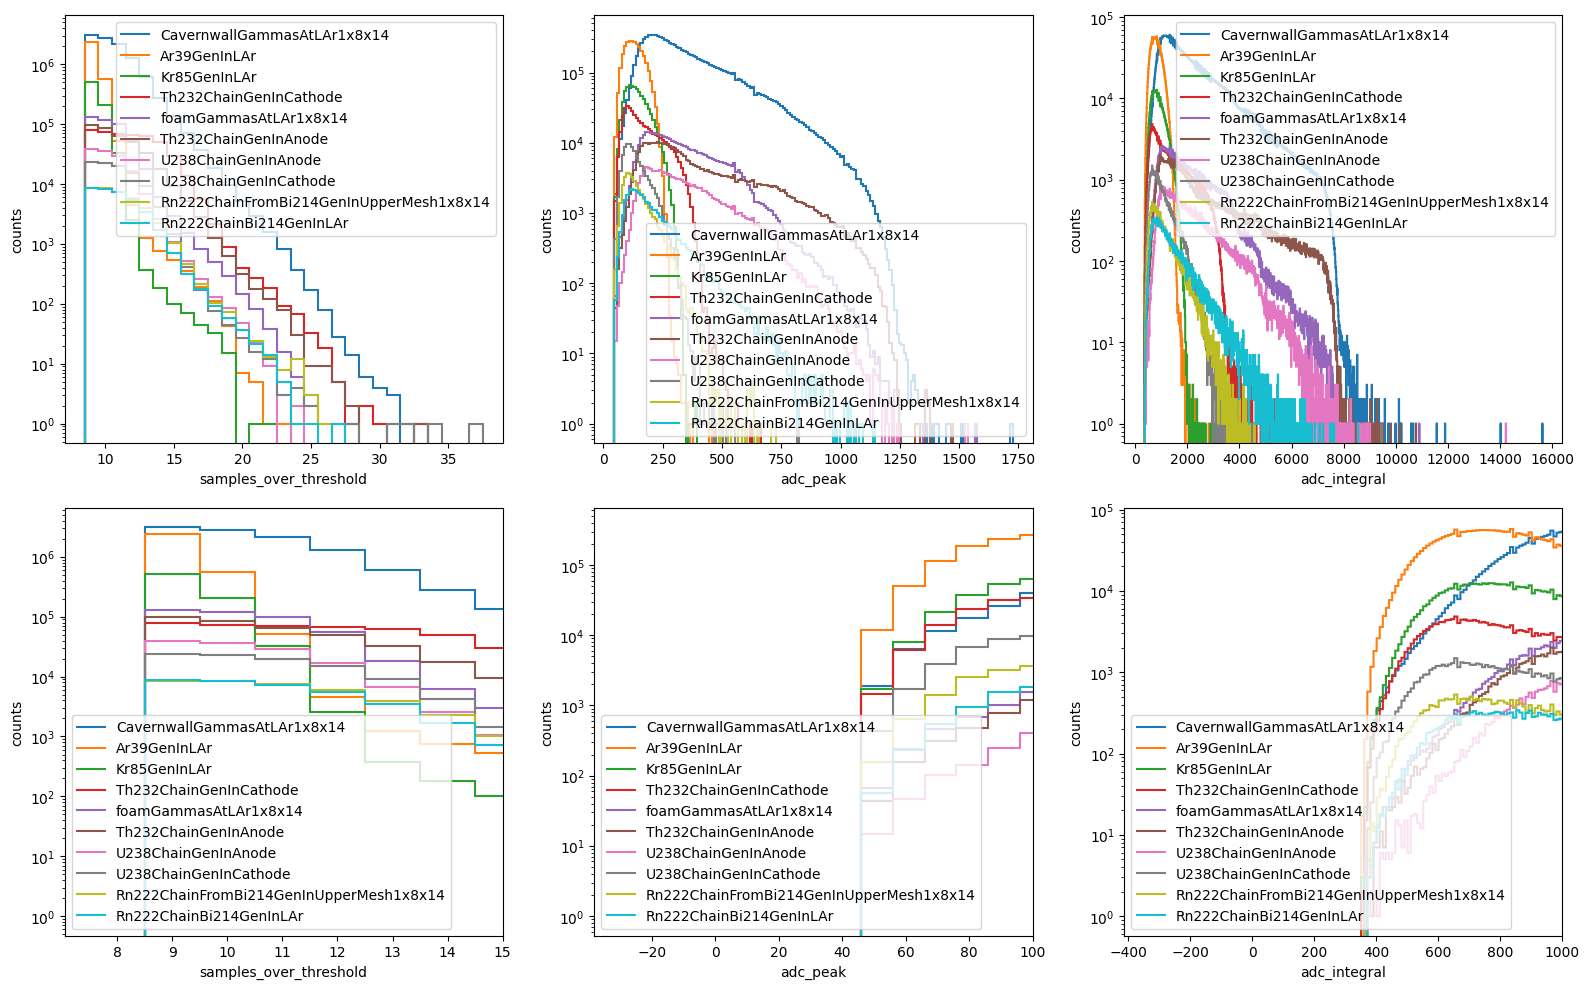

In [10]:
query=None
norm='rate'
geo_norm='crp'
n_top=10
rop=2


bkg_tpp = TrgPrimitivesPlotter(rad_ws)

fig, axes = plt.subplots(2, 3, figsize=(16,10))

bkg_tpp.plot_var_by_generator(query=query, rop=rop, n_top=n_top, var_spec='samples_over_threshold', ax=axes[0][0])
bkg_tpp.plot_var_by_generator(query=query, rop=rop,n_top=n_top, var_spec='adc_peak', ax=axes[0][1])
bkg_tpp.plot_var_by_generator(query=query, rop=rop, n_top=n_top, var_spec='adc_integral', ax=axes[0][2])

bkg_tpp.plot_var_by_generator(query=query, rop=rop, n_top=n_top, var_spec='samples_over_threshold', ax=axes[1][0])
axes[1][0].set_xlim(xmax=15)

bkg_tpp.plot_var_by_generator(query=query, rop=rop,n_top=n_top, var_spec='adc_peak', ax=axes[1][1])
axes[1][1].set_xlim(xmax=100)

bkg_tpp.plot_var_by_generator(query=query, rop=rop, n_top=n_top, var_spec='adc_integral', ax=axes[1][2])
axes[1][2].set_xlim(xmax=1000)


fig.tight_layout()

print(f"Min samples_over_threshold = {rad_ws.tps.samples_over_threshold.min()}")
print(f"Min adc_peak = {rad_ws.tps.adc_peak.min()}")
print(f"Min adc_integral = {rad_ws.tps.adc_integral.min()}")



Min samples_over_threshold = 9

Min adc_peak = 46

Min adc_integral = 351

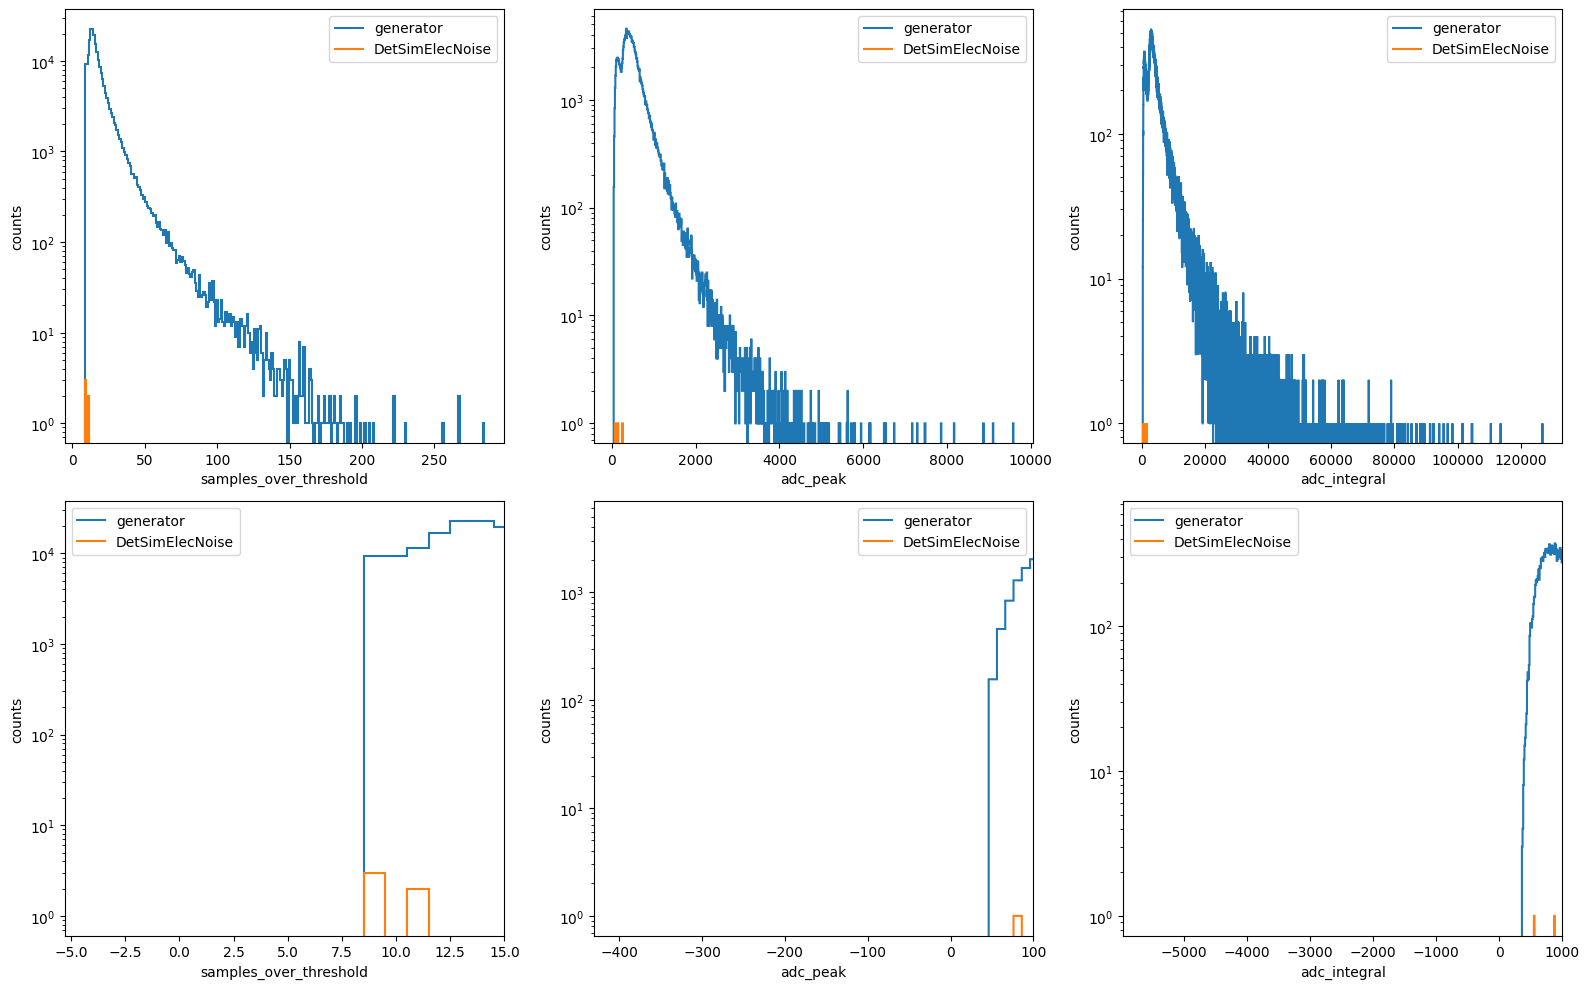

In [11]:
sig_tpp = TrgPrimitivesPlotter(em_ws)

fig, axes = plt.subplots(2, 3, figsize=(16,10))

sig_tpp.plot_var_by_generator(query=query, rop=rop, n_top=n_top, var_spec='samples_over_threshold', ax=axes[0][0])
sig_tpp.plot_var_by_generator(query=query, rop=rop,n_top=n_top, var_spec='adc_peak', ax=axes[0][1])
sig_tpp.plot_var_by_generator(query=query, rop=rop, n_top=n_top, var_spec='adc_integral', ax=axes[0][2])

sig_tpp.plot_var_by_generator(query=query, rop=rop, n_top=n_top, var_spec='samples_over_threshold', ax=axes[1][0])
axes[1][0].set_xlim(xmax=15)

sig_tpp.plot_var_by_generator(query=query, rop=rop,n_top=n_top, var_spec='adc_peak', ax=axes[1][1])
axes[1][1].set_xlim(xmax=100)

sig_tpp.plot_var_by_generator(query=query, rop=rop, n_top=n_top, var_spec='adc_integral', ax=axes[1][2])
axes[1][2].set_xlim(xmax=1000)


fig.tight_layout()

print(f"Min samples_over_threshold = {rad_ws.tps.samples_over_threshold.min()}")
print(f"Min adc_peak = {rad_ws.tps.adc_peak.min()}")
print(f"Min adc_integral = {rad_ws.tps.adc_integral.min()}")

In [12]:
bkg_tpp.make_generator_activity_table(geo_norm='crp')

                                       Rates per generator (crp)                                       
┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃    ┃ generator                               ┃ rate        ┃ rate_rop0  ┃ rate_rop1   ┃ rate_rop2   ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ 4  │ CavernwallGammasAtLAr1x8x14             │ 34009.98 Hz │ 1219.66 Hz │ 15094.12 Hz │ 17696.20 Hz │
│ 1  │ Ar39GenInLAr                            │ 6044.59 Hz  │ 2.37 Hz    │ 984.37 Hz   │ 5057.86 Hz  │
│ 11 │ Kr85GenInLAr                            │ 1614.00 Hz  │ 0.77 Hz    │ 351.19 Hz   │ 1262.03 Hz  │
│ 24 │ Th232ChainGenInCathode                  │ 1459.64 Hz  │ 247.79 Hz  │ 448.23 Hz   │ 763.62 Hz   │
│ 27 │ foamGammasAtLAr1x8x14                   │ 1380.63 Hz  │ 25.75 Hz   │ 624.31 Hz   │ 730.57 Hz   │
│ 23 │ Th232ChainGenInAnode                    │ 1245.83 Hz  │ 85.43 Hz   │ 540.13 Hz   │ 620.27 Hz   │
│ 0  │ DetSimElecNoise                         │ 947.25 Hz   │ 93.61 Hz   │ 852.00 Hz   │ 1.64 Hz     │
│ 25 │ U238ChainGenInAnode                     │ 424.75 Hz   │ 10.53 Hz   │ 191.42 Hz   │ 222.80 Hz   │
│ 26 │ U238ChainGenInCathode                   │ 258.68 Hz   │ 22.67 Hz   │ 72.93 Hz    │ 163.09 Hz   │
│ 14 │ Rn222ChainBi214GenInLAr                 │ 109.46 Hz   │ 8.91 Hz    │ 39.28 Hz    │ 61.28 Hz    │
│ 16 │ Rn222ChainFromBi214GenInUpperMesh1x8x14 │ 107.43 Hz   │ 11.71 Hz   │ 30.97 Hz    │ 64.75 Hz    │
│ 12 │ Rn220ChainFromPb212GenInUpperMesh1x8x14 │ 104.14 Hz   │ 15.89 Hz   │ 32.03 Hz    │ 56.22 Hz    │
│ 7  │ K40GenInAnode                           │ 96.48 Hz    │ 0.39 Hz    │ 44.42 Hz    │ 51.66 Hz    │
│ 13 │ Rn220ChainPb212GenInLAr                 │ 70.80 Hz    │ 8.79 Hz    │ 26.60 Hz    │ 35.41 Hz    │
│ 8  │ K40GenInCathode                         │ 45.72 Hz    │ 1.94 Hz    │ 12.87 Hz    │ 30.91 Hz    │
│ 10 │ K42From42ArGenInUpperMesh1x8x14         │ 22.03 Hz    │ 4.23 Hz    │ 7.06 Hz     │ 10.74 Hz    │
│ 20 │ Rn222ChainPb214GenInLAr                 │ 12.49 Hz    │ 0.01 Hz    │ 3.10 Hz     │ 9.38 Hz     │
│ 15 │ Rn222ChainFromBi210GenInUpperMesh1x8x14 │ 11.46 Hz    │ 0.10 Hz    │ 1.57 Hz     │ 9.78 Hz     │
│ 9  │ K42From42ArGenInLAr                     │ 5.69 Hz     │ 0.91 Hz    │ 2.14 Hz     │ 2.64 Hz     │
│ 18 │ Rn222ChainFromPb214GenInUpperMesh1x8x14 │ 2.18 Hz     │ 0.01 Hz    │ 0.14 Hz     │ 2.03 Hz     │
│ 2  │ Ar42GenInLAr                            │ 0.75 Hz     │ 0.00 Hz    │ 0.14 Hz     │ 0.61 Hz     │
│ 6  │ CryostatNGammasAtLAr1x8x14              │ 0.45 Hz     │ 0.08 Hz    │ 0.18 Hz     │ 0.19 Hz     │
│ 5  │ CavernwallNeutronsAtLAr1x8x14           │ 0.35 Hz     │ 0.01 Hz    │ 0.13 Hz     │ 0.21 Hz     │
│ 22 │ Rn222ChainRn222GenInLAr                 │ 0.01 Hz     │ 0.00 Hz    │ 0.01 Hz     │ 0.01 Hz     │
│ 3  │ CavernNGammasAtLAr1x8x14                │ 0.00 Hz     │ 0.00 Hz    │ 0.00 Hz     │ 0.00 Hz     │
│ 17 │ Rn222ChainFromPb210GenInUpperMesh1x8x14 │ 0.00 Hz     │ 0.00 Hz    │ 0.00 Hz     │ 0.00 Hz     │
│ 19 │ Rn222ChainPb210GenInLAr                 │ 0.00 Hz     │ 0.00 Hz    │ 0.00 Hz     │ 0.00 Hz     │
│ 21 │ Rn222ChainPo218GenInLAr                 │ 0.00 Hz     │ 0.00 Hz    │ 0.00 Hz     │ 0.00 Hz     │
└────┴─────────────────────────────────────────┴─────────────┴────────────┴─────────────┴─────────────┘

---

# Analyzer

In [ ]:

import hist
import mplhep as hep
import copy

from tpvalidator.detgeometry import get_by_geocfg_id

from typing import Optional
from tpvalidator.analysis.histograms import compute_regaxis_specs, cumsum_hist_nd, build_histogram, make_intcat_axis, make_strcat_axis

def make_wins(tps: pd.DataFrame):
    summary = (
        tps
        .groupby(['event_uid', 'TPCSetID', 'readout_plane_id','tawin_id'], observed=False, sort=False)
        .agg(
            n_tps=('tawin_id', "size"),
            sadc=("adc_integral", "sum"),
        )
        .reset_index()
    )

    return summary


class Calibrator:

    def __init__(self, m, b):
        self.m = m
        self.b = b
        
    def sadc_to_mev(self, sadc ):
        mev = sadc/self.m-self.b/self.m
        return mev

    def mev_to_sadc(self, mev ):
        sadc = self.m*mev+self.b
        return sadc


# TODO: Move to a dedicated module
class TrgWorkspaceAnalyzer:
    """Base class for analysers

    Returns:
        _type_: _description_
    """

    #-----------
    def __init__(self, ws):
        
        self.ws = ws
 
       # Initialize geometry
        self._geo = get_by_geocfg_id(ws.info['geo']['detector'])

    def simulated_readout_time(self) -> float:
        """Return total simulated time in seconds.

        Computed as ``2 × readout_window × num_entries × 0.5 µs``, where the
        factor of 2 accounts for pre- and post-spill readout windows.
        Always derived from ``ws.mctruths`` regardless of the active
        collection.
        """
        
        sampling_time = 0.5e-6  # Sampling time 1/2 usec
        ro_win = self.ws.extra_info['readout_window']
        num_entries = self.ws.extra_info['num_entries']
        return ro_win * sampling_time * num_entries

    

    @property
    def geo(self):
        return self._geo

class TAWindowAnalyzer(TrgWorkspaceAnalyzer):
    
    #-----------
    def __init__(self, ws, win_len):
        super(TAWindowAnalyzer, self).__init__(ws)

        self.win_len = win_len

        # initialization
        self.tps_in_win = self.ws.tps.copy()
        self.tps_in_win['tawin_id'] = self.tps_in_win.sample_peak // self.win_len

        self.ta_wins = make_wins(self.tps_in_win)

    #-----------
    def _apply_event_filter(self, df, event_filter:dict):
        evf_collection = event_filter['collection']
        evf_filter = event_filter['filter']

        coll = self.ws.get_df(evf_collection)

        ev_uids = coll.query(evf_filter).event_uid.unique()
        df = df[df.event_uid.isin(ev_uids)]

        return df


    #-----------
    def _get_cat_axis_list(self, df:pd.DataFrame, categories: list[str]) -> list[hist.axis.AxisProtocol]:
       
        h_spec = []
        for cat in categories:
            match cat:
                case 'readout_plane_id':
                    rop_axis = make_intcat_axis(df, 'readout_plane_id', label='Readout Plane')
                    h_spec.append(rop_axis)

                # case 'bt_is_signal':
                #     bt_sig_axis = make_intcat_axis(df, 'bt_is_signal', label='Noise/Signal')
                #     h_spec.append(bt_sig_axis)

                # case 'bt_generator_name':
                #     bt_gen_axis = make_strcat_axis(df, 'bt_generator_name', label='Generator')
                #     h_spec.append(bt_gen_axis)

                case _:
                    raise ValueError(f"Category {cat} not known")
                
        return h_spec
    


    #-----------
    def make_tawin_hist(self,
                var_spec:list[dict|str]|dict|str=[],
                categories: list[str]=['readout_plane_id'],
                weight: Optional[str]=None,
                query: Optional[str]=None,
                event_filter: Optional[dict]=None
            ):
        """Build a boost-histogram from the TP dataframe.

        Args:
            var_spec: Variable(s) to histogram. Each entry is either a string key
                into ``self.var_specs`` or a dict with keys ``name``, ``bin_size``,
                and optionally ``label`` and ``type``. A single dict is accepted
                in place of a one-element list.
            categories: Column names to use as categorical axes. Defaults to
                ``['readout_plane_id']``.
            weight: Column name whose values are used as per-entry weights.
            query: Pandas query string applied to the dataframe before filling.
            event_filter: Restrict entries to events that pass a filter on a
                different collection. Dict with keys ``'collection'`` (name passed
                to ``ws.get_df()``) and ``'filter'`` (query string applied to that
                collection); only rows whose ``event_uid`` appears in the filtered
                collection are kept.

        Returns:
            boost_histogram.Histogram with one categorical axis per category and
            one regular axis per variable.
        """
        df = self.ta_wins

        # TODO: generalize
        if event_filter:

            df = self._apply_event_filter(df, event_filter)


        if query:
            df = df.query(query)

        h_spec = self._get_cat_axis_list(df, categories)

        if isinstance(var_spec, dict):
            var_spec = [var_spec]

        for vs in var_spec:
            if isinstance(vs, str):
                vs = self.var_specs.get(vs)

            v_name = vs['name']
            v_bin_size = vs['bin_size']
            v_label = vs.get('label', v_name)
            v_type = vs.get('type', 'float')
            
            n_bins, xmin, xmax = compute_regaxis_specs(df[v_name], v_bin_size, binning_type=v_type)

            var_axis = hist.axis.Regular( n_bins, xmin, xmax, name=v_name, label=v_label)

            h_spec.append(var_axis)

        h = build_histogram(df, h_spec, weight=weight)
        return h

# Analysis

In [14]:
rad_twa = TAWindowAnalyzer(rad_ws, 1000)
em_twa = TAWindowAnalyzer(em_ws, 1000)

In [69]:
elec_calibrator = Calibrator(
    m = 2903.2,
    b = -5400
)

# Check the calibrator consistency
print(f"8000 sadcs -> {elec_calibrator.sadc_to_mev(8000):.2f} MeV")
print(f"5 MeV -> {elec_calibrator.mev_to_sadc(5):.2f} sadc")
print(f"sadc -> mev -> sadc : 8000 -> {elec_calibrator.mev_to_sadc(elec_calibrator.sadc_to_mev(8000))}")

8000 sadcs -> 4.62 MeV

5 MeV -> 9116.00 sadc

sadc -> mev -> sadc : 8000 -> 8000.000000000002

In [16]:
rad_twa.ta_wins.query('readout_plane_id == 2')

,event_uid,TPCSetID,readout_plane_id,tawin_id,n_tps,sadc
9,99010000001,62,2,8,1,795
10,99010000001,62,2,1,4,7024
11,99010000001,62,2,2,7,12769
12,99010000001,62,2,6,1,2467
13,99010000001,62,2,0,4,9650
...,...,...,...,...,...,...
9589569,99010162010,43,2,7,2,3590
9589570,99010162010,43,2,8,4,6765
9589571,99010162010,43,2,5,4,8097
9589572,99010162010,43,2,1,4,9998


## Check windows distributions
- Uniformity

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x121e87110>, errorbar=None, legend_artist=None)]

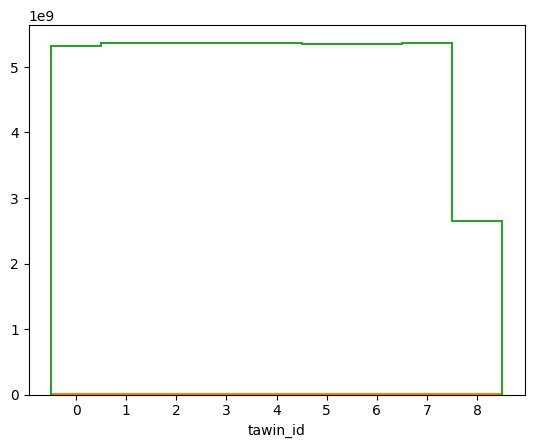

In [17]:
tawin_ax = hist.axis.Integer(0, rad_twa.ta_wins.tawin_id.max()+1, name='tawin_id')

h_tawin = hist.Hist(tawin_ax)
h_tawin.fill(tawin_id=rad_twa.ta_wins.tawin_id.values)

h_tawin_ntps = hist.Hist(tawin_ax)
h_tawin_ntps.fill(tawin_id=rad_twa.ta_wins.tawin_id.values, weight=rad_twa.ta_wins.n_tps)


h_tawin_sadc = hist.Hist(tawin_ax)
h_tawin_sadc.fill(tawin_id=rad_twa.ta_wins.tawin_id.values, weight=rad_twa.ta_wins.sadc)

hep.histplot(h_tawin)
hep.histplot(h_tawin_ntps)
hep.histplot(h_tawin_sadc)



## By readout plane (RadBkg)

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x11c91b770>, cbar=<matplotlib.colorbar.Colorbar object at 0x11c91b380>, text=[])

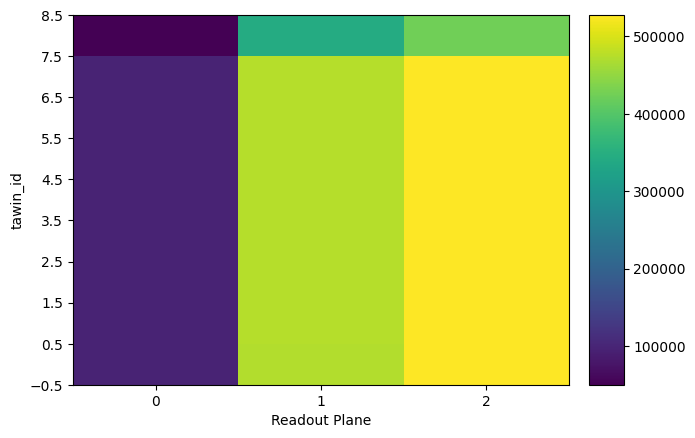

In [18]:
h = rad_twa.make_tawin_hist({'name':'tawin_id', 'bin_size': 1, 'type': 'int'})
hep.hist2dplot(h)

## SumADC and Num TPs for backgrounds and $e^-$

[(3.4438609623847336, 2.0060148152103756)]

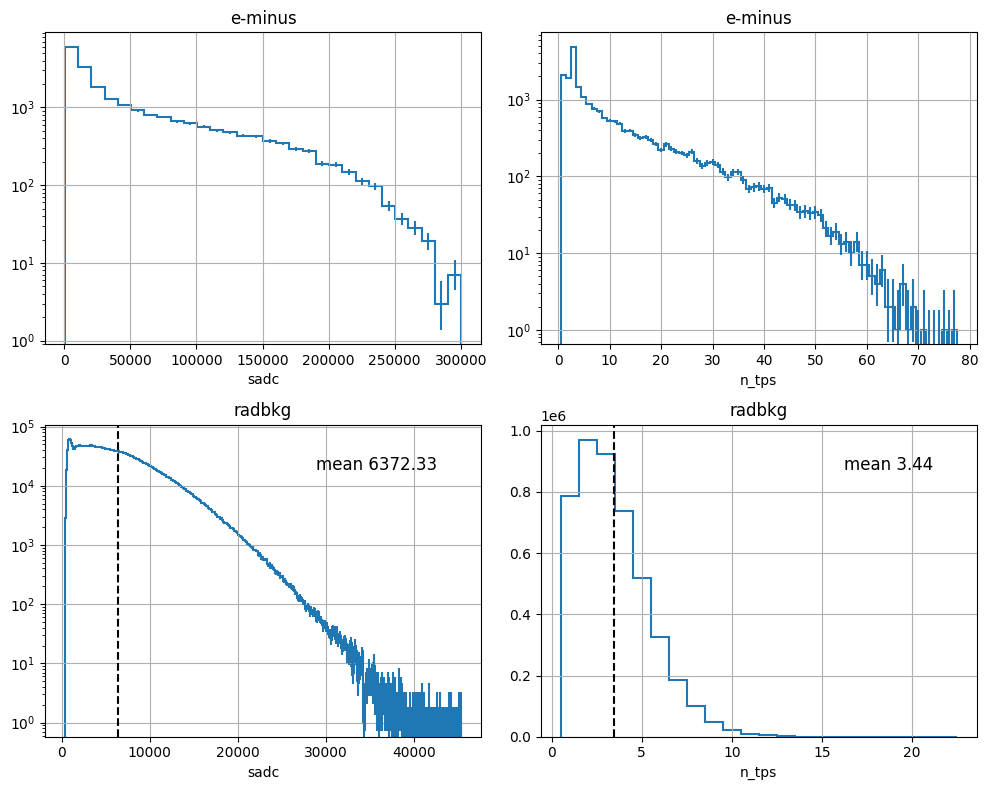

In [19]:
from tpvalidator.analysis.histograms import hist_stats


rop=2j

fig, axes = plt.subplots(2,2, figsize=(10,8))

ax=axes[0][0]
h = em_twa.make_tawin_hist({'name':'sadc', 'bin_size': 10000})
hep.histplot(h[rop,:], ax=ax)
ax.set_yscale('log')
ax.set_title('e-minus')
ax.grid()


ax=axes[0][1]
h = em_twa.make_tawin_hist({'name':'n_tps', 'bin_size': 1, 'type': 'int'})
hep.histplot(h[rop,:], ax=ax)
ax.set_yscale('log')
ax.set_title('e-minus')
ax.grid()

ax=axes[1][0]
h = rad_twa.make_tawin_hist({'name':'sadc', 'bin_size': 100})
hep.histplot(h[rop,:], ax=ax)
ax.set_yscale('log')
ax.set_title('radbkg')
mean, std = hist_stats(h[rop,:])[0]


ax.axvline(mean, c='k', ls='--')
ax.text(0.9, 0.9, f"mean {mean:.2f}", transform=ax.transAxes, fontsize=12,
            verticalalignment='top', horizontalalignment='right')
ax.grid()


ax=axes[1][1]
h = rad_twa.make_tawin_hist({'name':'n_tps', 'bin_size': 1, 'type': 'int'})
hep.histplot(h[rop,:], ax=ax)
print(hist_stats(h[rop,:]))
ax.set_title('radbkg')

mean, std = hist_stats(h[rop,:])[0]


ax.axvline(mean, c='k', ls='--')
ax.text(0.9, 0.9, f"mean {mean:.2f}", transform=ax.transAxes, fontsize=12,
            verticalalignment='top', horizontalalignment='right')
ax.grid()

fig.tight_layout()

### 2D distributions

In [20]:
h_em = em_twa.make_tawin_hist([{'name':'n_tps', 'bin_size': 1, 'type': 'int'}, {'name':'sadc', 'bin_size': 100}])
h_rad = rad_twa.make_tawin_hist([{'name':'n_tps', 'bin_size': 1, 'type': 'int'}, {'name':'sadc', 'bin_size': 100}])



ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x126b96710>, cbar=<matplotlib.colorbar.Colorbar object at 0x126bedd10>, text=[])

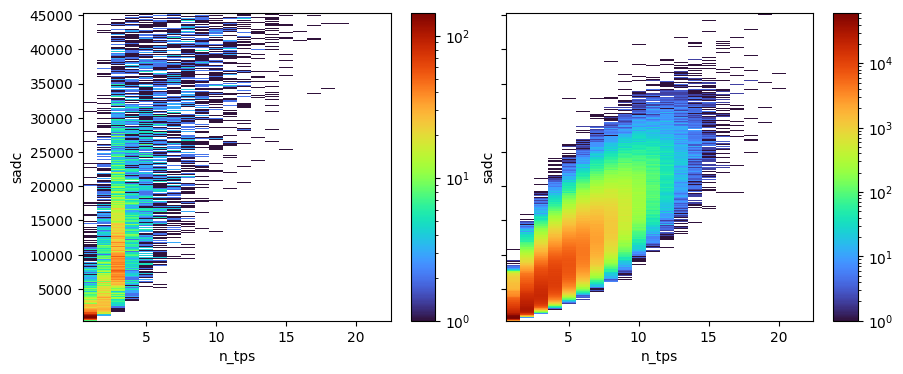

In [21]:
from matplotlib.colors import LogNorm


fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
hep.hist2dplot(h_em[rop,:,:], cmap='turbo', norm=LogNorm(), ax=axes[0])
hep.hist2dplot(h_rad[rop,:,:], cmap='turbo', norm=LogNorm(), ax=axes[1])


## Compare e- max-adc / event with radbkg sadc distro

In [22]:
em_sadc_max = (em_twa.ta_wins
 .groupby('event_uid', sort=False)
 .agg(
    sadc_max=('sadc', "max"),
    n_win=('tawin_id', "size"),
    )
)


rad_sadc_max = (rad_twa.ta_wins
 .groupby('event_uid', sort=False)
 .agg(
    sadc_max=('sadc', "max"),
    n_win=('tawin_id', "size"),
    )
)

display(rad_sadc_max)

,sadc_max,n_win
event_uid,,
99010000001,27249,1904
99010000002,34243,1921
99010000003,24045,1908
99010000004,32314,1909
99010000005,23876,1948
...,...,...
99010162006,25814,1915
99010162007,29788,1860
99010162008,26089,1898


Text(0.5, 1.0, 'radbkg - win sadc')

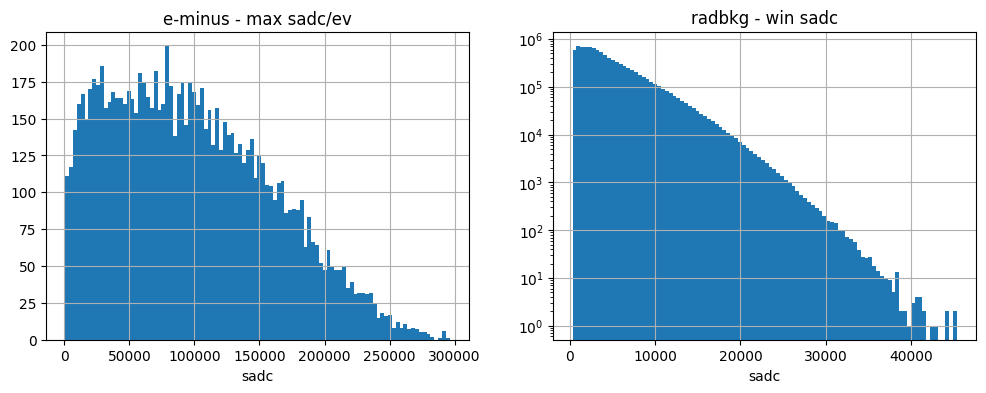

In [23]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

ax=axes[0]
em_sadc_max.sadc_max.hist(bins=100, ax=ax)

ax.set_title('e-minus - max sadc/ev')
ax.set_xlabel('sadc')


ax=axes[1]
rad_twa.ta_wins.sadc.hist(bins=100, ax=ax)
ax.set_yscale('log')
ax.set_xlabel('sadc')
ax.set_title('radbkg - win sadc')

### Observations
- Radiological window have a max sadc value of ~40k
---

## Cluster making

### Define inspect windows and estimate inspect rate

- Select windows with charge above the radbkg average and below the bkg endpoint.
- Check TP multiplicity in inspect windows

┌───────────────────────────────────────────────────┬──────────────┐
│ Window length                                     │ 1000 samples │
│ Window length                                     │ 0.0005 s     │
│ Num CRP                                           │ 28.0         │
│ Simulated readout time                            │ 2.1e+01s     │
│ Number of window expected per TPC                 │ 42500.0      │
│ Number of window expected (total)                 │ 4760000.0    │
│ Total number of windows (all planes)              │ 9589574      │
│ Total number of collection windows in the dataset │ 4639579      │
│ Number of windows per CRP                         │ 342484.79    │
│ Windows rate per CRP                              │ 16116.93 Hz  │
│ Selected inspect windows                          │ 1609649      │
│ Selected inspect windows ratio                    │ 0.17         │
│ Inspect rate per CRP                              │ 2705.29 Hz   │
└───────────────────────────────────────────────────┴──────────────┘

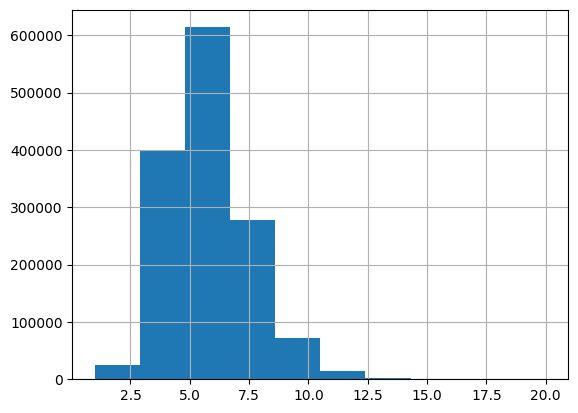

In [41]:
rop =2 
min_sadc = 8000
max_sadc = 50000
rad_insp_win = rad_twa.ta_wins.query(f'sadc > {min_sadc} & sadc < {max_sadc}')

rad_insp_win.query(f'readout_plane_id == {rop}').n_tps.hist()

rows = [
    ("Window length", f"{rad_twa.win_len} samples"),
    ("Window length", f"{rad_twa.win_len*0.5e-6} s"),
    ("Num CRP", f"{rad_twa.geo.num_crps}"),
    ("Simulated readout time", f"{rad_twa.simulated_readout_time():.2}s"),
    ("Number of window expected per TPC", f"{rad_twa.simulated_readout_time()/(rad_twa.win_len*0.5e-6):.1f}"),
    ("Number of window expected (total)", f"{rad_twa.simulated_readout_time()/(rad_twa.win_len*0.5e-6)*rad_twa.geo.num_tpcs:.1f}"),
    ("Total number of windows (all planes)", f"{len(rad_twa.ta_wins)}"),
    ("Total number of collection windows in the dataset", f"{len(rad_twa.ta_wins.query('readout_plane_id == 2'))}"),
    ("Number of windows per CRP", f"{len(rad_twa.ta_wins)/rad_twa.geo.num_crps:.2f}"),
    ("Windows rate per CRP", f"{len(rad_twa.ta_wins)/(rad_twa.geo.num_crps*rad_twa.simulated_readout_time()):.2f} Hz"),


    ("Selected inspect windows",f"{len(rad_insp_win)}"),
    ("Selected inspect windows ratio",f"{len(rad_insp_win)/len(rad_twa.ta_wins):.2f}"),
    ("Inspect rate per CRP", f"{len(rad_insp_win)/(rad_twa.simulated_readout_time()*rad_twa.geo.num_crps):.2f} Hz"),
    # All wins {len(rad_twa.ta_wins)} -> inspect {len(rad_insp_win)} ({len(rad_insp_win)/len(rad_twa.ta_wins):.3})
]

from rich.table import Table
t = Table(show_header=False)

for r in rows:

    t.add_row(r[0], f'[bold]{r[1]}[/bold]')


print(t)

## Collect TPs in the inspect windows and run the clustering algorithm

In [25]:
keys = ['event_uid', 'TPCSetID', 'readout_plane_id', 'tawin_id']
rad_insp_tps = rad_twa.tps_in_win.join(rad_insp_win.assign(_keep=True).set_index(keys), on=keys)

rad_insp_tps

mask  TPCSetID  adc_integral  adc_peak   bt_edep  \
entry subentry                                                     
0     0            0        62           765       122  0.830786   
      1            0        62          3247       581  2.353353   
      2            0        62           565        68  0.284733   
      3            0        62          1676       237  1.036893   
      4            0        62           446        64  0.366180   
...              ...       ...           ...       ...       ...   
4999  5562         0        43          3008       492  1.085904   
      5563         0        43          3198       520  1.079461   
      5564         0        43           516        66  0.271317   
      5565         0        43          1283       228  0.558451   
      5566         0        43           744       125  0.273138   

                          bt_generator_name  bt_numelectrons  \
entry subentry                                                 
0     0                     K40GenInCathode     15291.539062   
      1         CavernwallGammasAtLAr1x8x14     67526.000000   
      2         CavernwallGammasAtLAr1x8x14      5350.000000   
      3         CavernwallGammasAtLAr1x8x14     28729.000000   
      4                        Ar39GenInLAr      8518.613281   
...                                     ...              ...   
4999  5562      CavernwallGammasAtLAr1x8x14     27379.000000   
      5563      CavernwallGammasAtLAr1x8x14     29722.000000   
      5564                     Ar39GenInLAr      4831.138076   
      5565      CavernwallGammasAtLAr1x8x14     13345.000000   
      5566      CavernwallGammasAtLAr1x8x14      5881.000000   

                bt_primary_track_energy_frac  bt_primary_track_id  \
entry subentry                                                      
0     0                                  1.0               127281   
      1                                  1.0                98815   
      2                                  1.0               110405   
      3                                  1.0                94019   
      4                                  1.0                 7408   
...                                      ...                  ...   
4999  5562                               1.0               113564   
      5563                               1.0                86567   
      5564                               1.0                31538   
      5565                               1.0                99383   
      5566                               1.0               106692   

                bt_primary_track_numelectron_frac  ...  subrun    event_uid  \
entry subentry                                     ...                        
0     0                                       1.0  ...       0  99010000001   
      1                                       1.0  ...       0  99010000001   
      2                                       1.0  ...       0  99010000001   
      3                                       1.0  ...       0  99010000001   
      4                                       1.0  ...       0  99010000001   
...                                           ...  ...     ...          ...   
4999  5562                                    1.0  ...    1620  99010162010   
      5563                                    1.0  ...    1620  99010162010   
      5564                                    1.0  ...    1620  99010162010   
      5565                                    1.0  ...    1620  99010162010   
      5566                                    1.0  ...    1620  99010162010   

                time_peak  sample_start  sample_peak  bt_is_signal  tawin_id  \
entry subentry                                                                 
0     0            185088          5779         5784             1         5   
      1            159456          4977         4983             1         4   
      2            129568          4048         4049

In [26]:
rad_insp_tps = rad_insp_tps[rad_insp_tps["_keep"] == True]
print(f'tps count = {len(rad_twa.tps_in_win)}, rad_insp_tps tps count {len(rad_insp_tps)}, ({len(rad_insp_tps)/len(rad_twa.tps_in_win):.3})')

tps count = 28545010, rad_insp_tps tps count 10190089, (0.357)

In [27]:
from tpvalidator.algo.tafinder.trigger_algs_numba import apply_dbscan
from tqdm import tqdm
tqdm.pandas(desc="numba tafinder!")

### Create radiological windows and calculate entries and sum adc for each

tas3 = (
    rad_insp_tps
    .groupby(['event_uid', 'TPCSetID', 'readout_plane_id', 'tawin_id'], sort=False)
    .progress_apply(apply_dbscan, include_groups = False)
    .reset_index()
)

numba tafinder!: 100%|██████████| 1833454/1833454 [1:48:41<00:00, 281.13it/s]  


In [64]:
rad_insp_tps.loc[tas3['tp_index'].iloc[5]]


print(tas3.n_clusters)
tas3['dbscan_label']

tas3.apply(
    lambda row: [(*pair, val) for pair, val in zip(row["tp_index"], row["dbscan_label"]) if val != -1],
    axis=1
)

0          1
2          2
4          1
7          1
8          1
          ..
1833444    1
1833445    1
1833449    1
1833450    1
1833453    1
Name: n_clusters, Length: 727618, dtype: int64

0                                  [(0, 48, 0), (0, 49, 0)]
2          [(0, 35, 0), (0, 36, 0), (0, 37, 1), (0, 38, 1)]
4                                  [(0, 69, 0), (0, 70, 0)]
7                                [(0, 118, 0), (0, 119, 0)]
8                                [(0, 133, 0), (0, 134, 0)]
                                 ...                       
1833444                  [(4999, 5439, 0), (4999, 5440, 0)]
1833445                  [(4999, 5458, 0), (4999, 5459, 0)]
1833449                  [(4999, 5504, 0), (4999, 5505, 0)]
1833450                  [(4999, 5556, 0), (4999, 5557, 0)]
1833453                  [(4999, 5549, 0), (4999, 5550, 0)]
Length: 727618, dtype: object

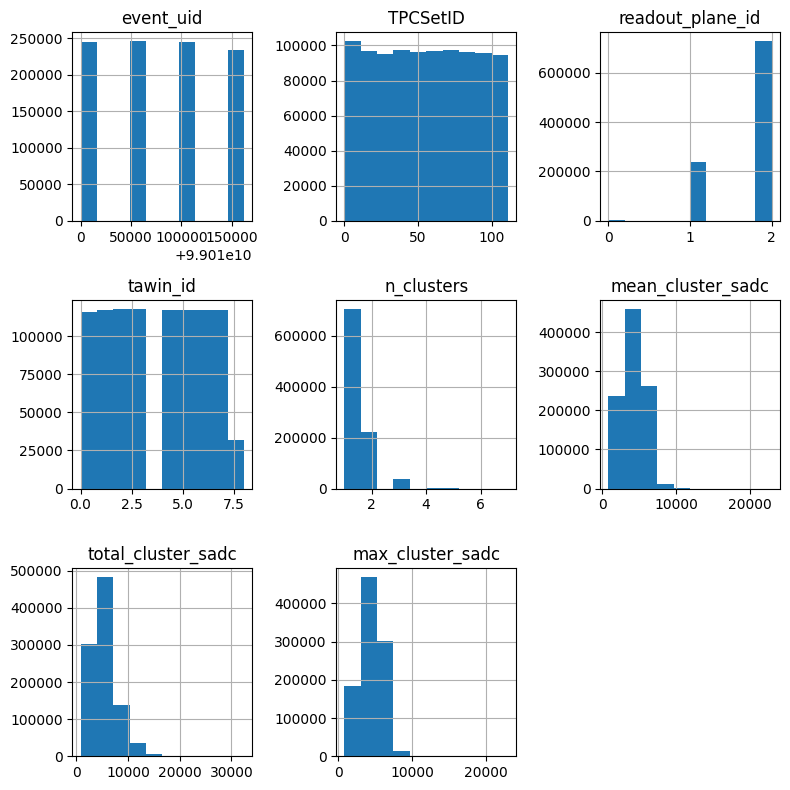

In [33]:
tas3.hist(figsize=(8,8))
plt.tight_layout()


In [35]:
tas3

,event_uid,TPCSetID,readout_plane_id,tawin_id,n_clusters,mean_cluster_sadc,total_cluster_sadc,max_cluster_sadc,tp_index,dbscan_label
0,99010000001,62,2,2,1,3543.0,3543,3543,"[(0, 25), (0, 31), (0, 32), (0, 34), (0, 47), ...","[-1, -1, -1, -1, -1, 0, 0]"
2,99010000001,62,2,5,2,3231.5,6463,4378,"[(0, 35), (0, 36), (0, 37), (0, 38), (0, 44)]","[0, 0, 1, 1, -1]"
4,99010000001,0,2,1,1,4349.0,4349,4349,"[(0, 69), (0, 70), (0, 83), (0, 84), (0, 87)]","[0, 0, -1, -1, -1]"
5,99010000001,4,1,5,2,3780.5,7561,4923,"[(0, 100), (0, 102), (0, 103), (0, 108), (0, 1...","[-1, 0, 0, 1, 1]"
7,99010000001,4,2,4,1,3596.0,3596,3596,"[(0, 111), (0, 118), (0, 119), (0, 123), (0, 1...","[-1, 0, 0, -1, -1, -1]"
...,...,...,...,...,...,...,...,...,...,...
1833445,99010162010,86,2,3,1,7045.0,7045,7045,"[(4999, 5443), (4999, 5445), (4999, 5453), (49...","[-1, -1, -1, -1, -1, 0, 0]"
1833446,99010162010,82,1,6,2,2537.5,5075,3327,"[(4999, 5467), (4999, 5469), (4999, 5470), (49...","[-1, 0, 0, 1, 1, -1, -1]"
1833449,99010162010,82,2,3,1,6859.0,6859,6859,"[(4999, 5502), (4999, 5504), (4999, 5505), (49...","[-1, 0, 0, -1, -1]"
1833450,99010162010,43,2,4,1,3811.0,3811,3811,"[(4999, 5539), (4999, 5540), (4999, 5544), (49...","[-1, -1, -1, -1, 0, 0]"


4.615596583080739

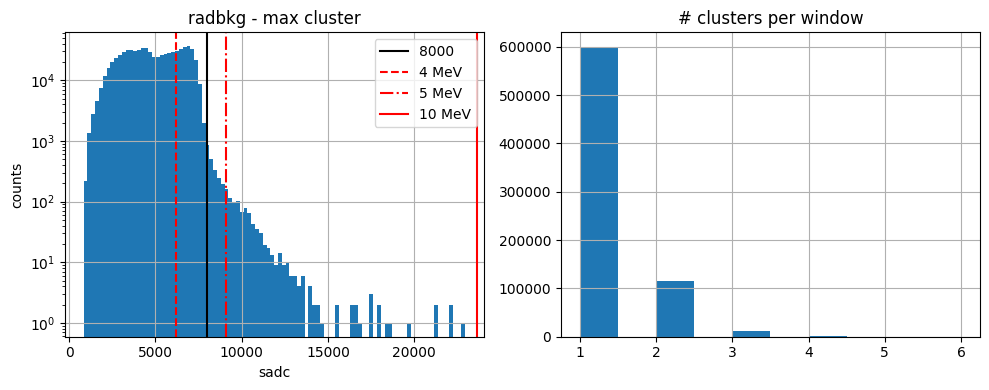

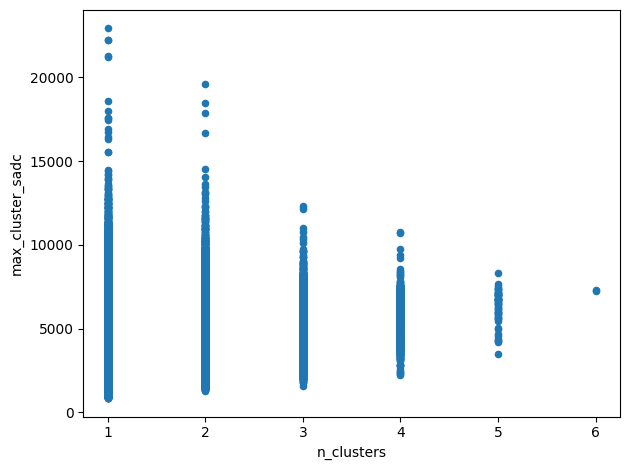

In [78]:
tas3.query('readout_plane_id==2 & n_clusters > 0', inplace=True)

fig, axes = plt.subplots(1,2, figsize=(10,4))
ax=axes[0]
tas3.max_cluster_sadc.hist(bins=100, ax=ax)

sadc_1Mev = 2.277e3

sadc_line = 8000
ax.axvline(x=8000, c='k', label='8000')

print(elec_calibrator.sadc_to_mev(8000))
energy = 4
ax.axvline(x=elec_calibrator.mev_to_sadc(energy), c='r', ls='--', label=f'{energy} MeV')
energy = 5
ax.axvline(x=elec_calibrator.mev_to_sadc(energy), c='r', ls='-.', label=f'{energy} MeV')
energy = 10
ax.axvline(x=elec_calibrator.mev_to_sadc(energy), c='r', ls='-', label=f'{energy} MeV')

# ax.set_yscale('log')
ax.set_xlabel('sadc')
ax.set_ylabel('counts')
ax.set_title('radbkg - max cluster')
ax.set_yscale('log')
ax.legend()

ax=axes[1]
tas3.n_clusters.hist(ax=ax)
ax.set_title('# clusters per window')

fig.tight_layout()


fig, axes = plt.subplots(1,1)
ax=axes
tas3.plot.scatter(x='n_clusters', y='max_cluster_sadc', ax=ax)
fig.tight_layout()
